# 区间估计与Bootstrap

## Goal
给一个估计值配上有清楚概率含义的区间。先手算和完全枚举，再执行配对/分组重采样，最后用已知真值测覆盖率。正文完整推导在lecture.pdf；实验步骤在lab.pdf；18题完整解答在answers.pdf。

基线实际结果：已知σ Gaussian区间2867/3000次覆盖；非参数百分位2797/3000；组模型按行590/1000，按组936/1000。它们是指定种子与有限B、R的实际运行值，不是所有分布的性质。Wald在n=20、p=.02处的精确覆盖约.331792，无Monte Carlo误差。

## Setup
从本单元目录启动并Restart Kernel / Run All。代码从experiment模块定位输入，不读取以前的outputs报告。所有输入是合成数据，不联网。第一格核验默认CSV/config；修改实验请复制JSON并用脚本--spec运行，重新解释结果。

### Key Assumptions
已知σ实验：独立同分布Gaussian。配对实验：个体独立、同一个体两列一起抽。组实验：组独立、组内共享Gaussian效应、组大小相同。Bootstrap采用有放回和逆经验CDF分位数。后验区间条件于Beta(2,2)先验与Bernoulli似然。

In [1]:
import sys, math, io, csv
from fractions import Fraction
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.facecolor':'white'})
def show(fig):
    fig.tight_layout(pad=1.5)
    buf=io.BytesIO();fig.savefig(buf,format='png',dpi=140,bbox_inches='tight')
    plt.close(fig);display(Image(data=buf.getvalue()))
x=e.load_csv(e.ROOT/'data/tiny_sample.csv')
spec=e.load_spec()
e.require(x.tolist()==[0,2], 'This tutorial requires baseline tiny sample')
e.require(spec=={'kind':'synthetic_interval_coverage','seed':25025,'normal_repetitions':3000,'group_repetitions':1000,'B':399,'n':20,'G':24,'m':6,'mu':3.0,'sigma':.5,'tau':2.0}, 'Use script --spec for changed configuration')
with (e.ROOT/'data/paired.csv').open(newline='') as f:paired_rows=list(csv.reader(f))
with (e.ROOT/'data/grouped.csv').open(newline='') as f:grouped_rows=list(csv.reader(f))
e.require(paired_rows==[['subject','before','after'],['P1','1','2'],['P2','2','3'],['P3','4','5'],['P4','8','9']], 'baseline paired CSV changed')
e.require(grouped_rows==[['group','replicate','value'],['A','1','0'],['A','2','0'],['B','1','2'],['B','2','2'],['C','1','4'],['C','2','4']], 'baseline grouped CSV changed')
print({'Python':sys.version.split()[0],'NumPy':np.__version__,'Matplotlib':matplotlib.__version__,'BitGenerator':'PCG64'})
print(spec)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8', 'BitGenerator': 'PCG64'}
{'kind': 'synthetic_interval_coverage', 'seed': 25025, 'normal_repetitions': 3000, 'group_repetitions': 1000, 'B': 399, 'n': 20, 'G': 24, 'm': 6, 'mu': 3.0, 'sigma': 0.5, 'tau': 2.0}


## Steps
### 1. 已知标准差的手算与标准化
均值10；标准误2/√4=1；z=.975标准正态分位数。精确95%依赖Gaussian闭合性和σ已知。下图展示区间与独立样本量的关系。

mean=10, SE=1, endpoints= [8.040036015459947, 11.959963984540053]


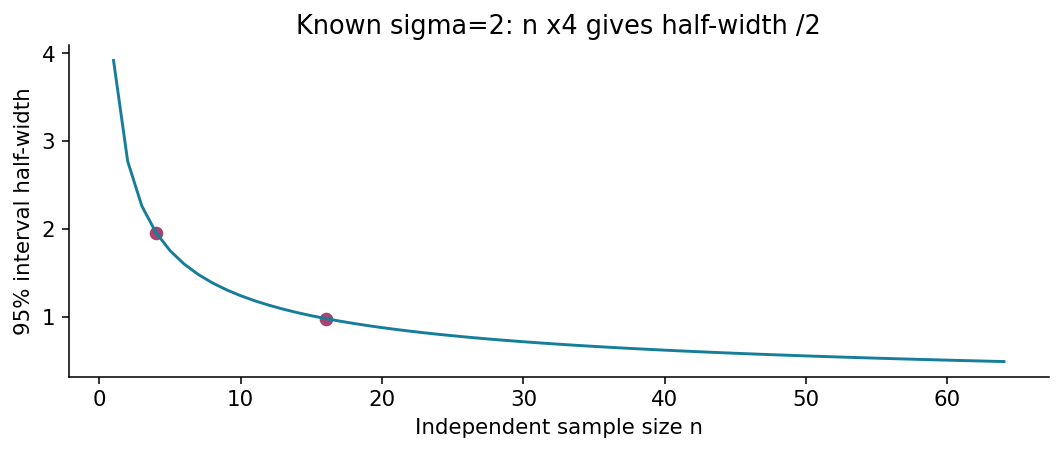

In [2]:
ci=e.known_sigma_interval([9,10,11,10],2)
print('mean=10, SE=1, endpoints=',ci)
e.require(abs(ci[0]-(10-e.Z95))<1e-14,'hand interval')
fig,ax=plt.subplots(figsize=(8,3.5));ns=np.arange(1,65)
ax.plot(ns,e.Z95*2/np.sqrt(ns),color='#167d9a')
ax.scatter([4,16],[e.Z95,e.Z95/2],color='#a54572')
ax.set(xlabel='Independent sample size n',ylabel='95% interval half-width',title='Known sigma=2: n x4 gives half-width /2')
show(fig)

### 2. 完全枚举(0,2)的Bootstrap
索引共有2²=4种有序结果，均值概率为1/4、1/2、1/4。这里直接用Fraction计算条件矩，独立于随机模拟。

{'mean': 0.0, 'exact_mean': '0', 'count': 1, 'total': 4}
{'mean': 1.0, 'exact_mean': '1', 'count': 2, 'total': 4}
{'mean': 2.0, 'exact_mean': '2', 'count': 1, 'total': 4}
Exact conditional mean: 1 variance: 1/2 SE: 0.7071067811865476
Percentile endpoints: 0.0 2.0


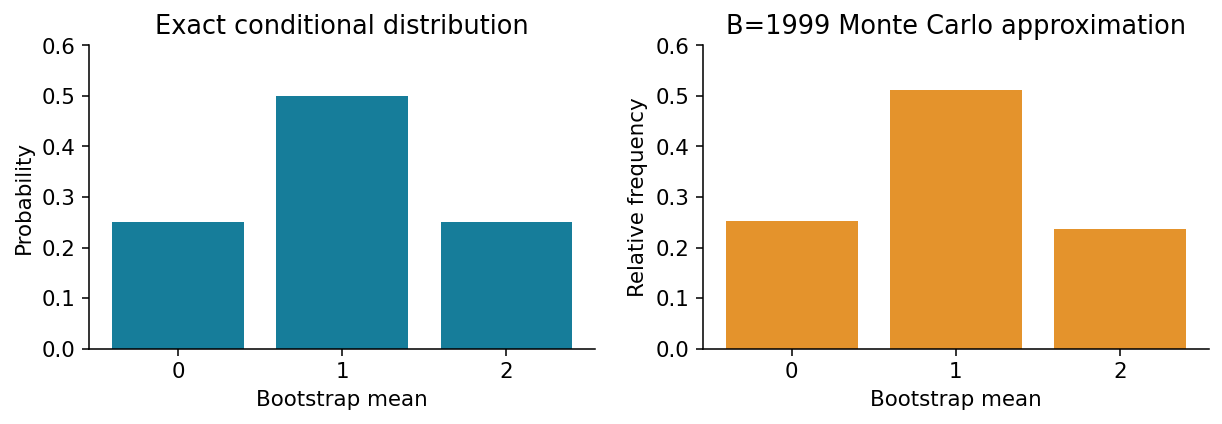

In [3]:
rows=e.exact_bootstrap(x)
for row in rows:print(row)
m=sum(Fraction(row['count'],row['total'])*Fraction(row['exact_mean']) for row in rows)
v=sum(Fraction(row['count'],row['total'])*(Fraction(row['exact_mean'])-m)**2 for row in rows)
e.require(m==1 and v==Fraction(1,2),'exact moments')
print('Exact conditional mean:',m,'variance:',v,'SE:',math.sqrt(float(v)))
print('Percentile endpoints:',e.weighted_quantile([0,1,2],[1,2,1],.025),e.weighted_quantile([0,1,2],[1,2,1],.975))
fig,axes=plt.subplots(1,2,figsize=(9,3.3))
axes[0].bar([0,1,2],[.25,.5,.25],color='#167d9a');axes[0].set(title='Exact conditional distribution',xlabel='Bootstrap mean',ylabel='Probability',xticks=[0,1,2],ylim=(0,.6))
boot=e.bootstrap_mean(x,1999,25025)
axes[1].bar([0,1,2],[np.mean(boot==v) for v in [0,1,2]],color='#e4932c');axes[1].set(title='B=1999 Monte Carlo approximation',xlabel='Bootstrap mean',ylabel='Relative frequency',xticks=[0,1,2],ylim=(0,.6))
show(fig)

### 3. 后验可信区间
第24讲Beta(2,2)先验加八次三成功产生Beta(5,7)。使用正整数形状CDF的有限和与二分，明确只在受限形状和尾部范围内实现。这里的0.95是给定数据后的后验质量。

Credible interval: 0.16748809406370713 0.6920952849883226
CDF at endpoints: 0.02499999999999999 0.9749999999999999


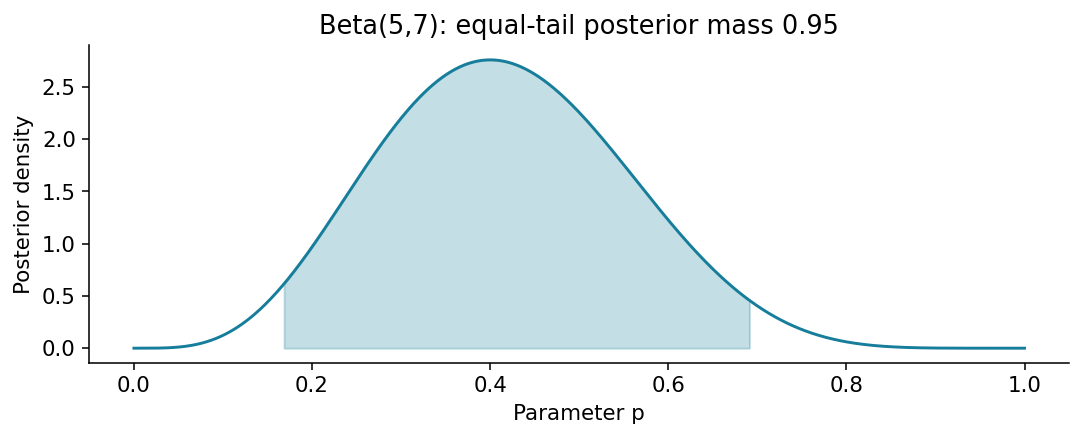

In [4]:
qlo=e.beta_quantile_integer(.025,5,7);qhi=e.beta_quantile_integer(.975,5,7)
print('Credible interval:',qlo,qhi)
print('CDF at endpoints:',e.beta_cdf_integer(qlo,5,7),e.beta_cdf_integer(qhi,5,7))
e.require(abs(e.beta_cdf_integer(qlo,5,7)-.025)<1e-13,'low residual')
e.require(abs(e.beta_cdf_integer(qhi,5,7)-.975)<1e-13,'high residual')
p=np.linspace(0,1,600);density=2310*p**4*(1-p)**6
fig,ax=plt.subplots(figsize=(8,3.4));ax.plot(p,density,color='#167d9a')
ax.fill_between(p,0,density,where=(p>=qlo)&(p<=qhi),alpha=.25,color='#167d9a')
ax.set(xlabel='Parameter p',ylabel='Posterior density',title='Beta(5,7): equal-tail posterior mass 0.95')
show(fig)

### 4. Wald边界与精确覆盖
不需要Monte Carlo。枚举K=0到20并以二项概率加权；真实p=.02时只有K=1、2、3覆盖。注意图上台阶来自离散覆盖事件。

P(K=0)= 0.6676079717550942 Wald for K=0: [0.0, 0.0]
Covering k: [1, 2, 3] exact coverage: 0.3317923493486588


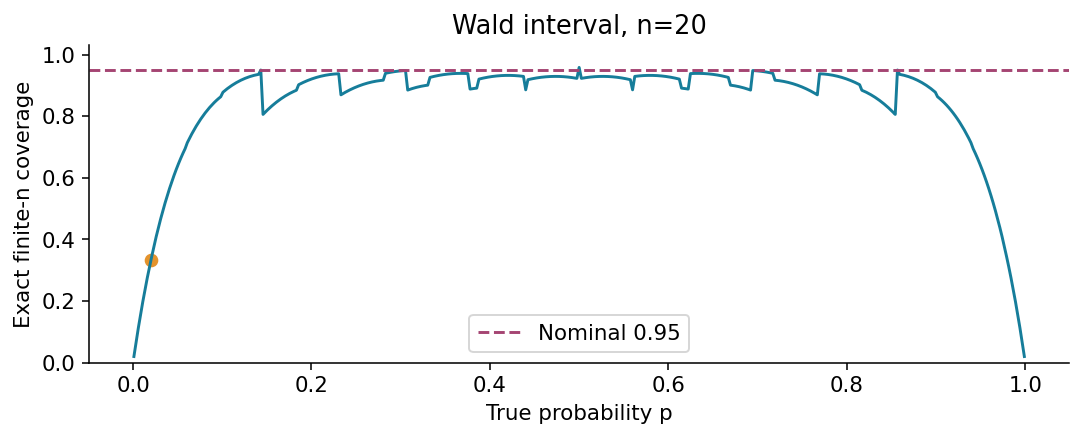

In [5]:
print('P(K=0)=',.98**20,'Wald for K=0:',e.wald_interval(0,20))
covering=[]
for k in range(21):
    lo,hi=e.wald_interval(k,20)
    if lo<=.02<=hi:covering.append(k)
print('Covering k:',covering,'exact coverage:',e.exact_wald_coverage(.02,20))
e.require(covering==[1,2,3],'covering counts')
ps=np.linspace(.001,.999,401);cov=[e.exact_wald_coverage(float(p),20) for p in ps]
fig,ax=plt.subplots(figsize=(8,3.4));ax.plot(ps,cov,color='#167d9a');ax.axhline(.95,color='#a54572',ls='--',label='Nominal 0.95')
ax.scatter([.02],[e.exact_wald_coverage(.02,20)],color='#e4932c')
ax.set(xlabel='True probability p',ylabel='Exact finite-n coverage',ylim=(0,1.03),title='Wald interval, n=20');ax.legend()
show(fig)

### 5. 配对保留两列的对应关系
由核验过的CSV读取数值；同一subject两列使用同一索引。恒定增量的条件标准差必须精确为0。独立抽列模拟另一个采样设计。

Paired SE: 0.0 independent simulated SE: 1.9005980251340073
Independent exact conditional variance: 3.59375


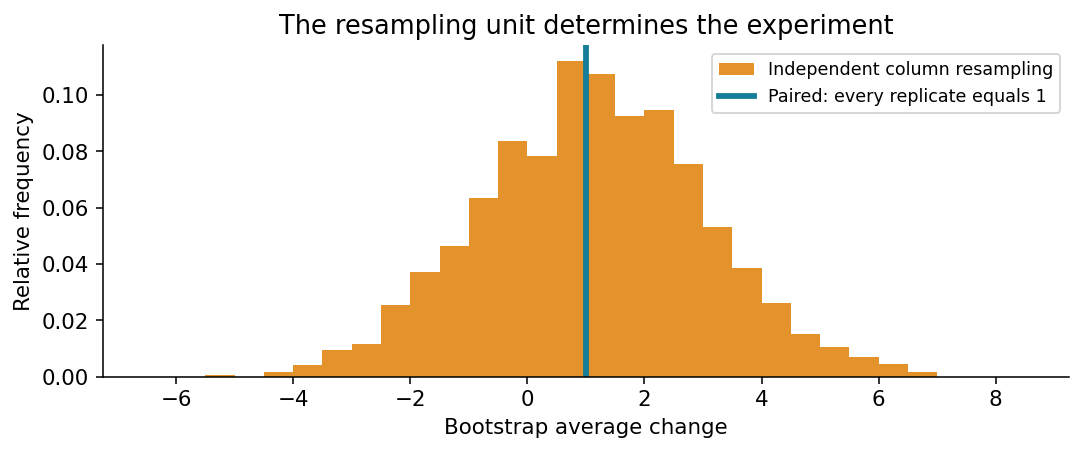

In [6]:
before=[e.csv_number(row[1],'before') for row in paired_rows[1:]]
after=[e.csv_number(row[2],'after') for row in paired_rows[1:]]
pair=e.paired_bootstrap(before,after,1999,25025,'paired')
ind=e.paired_bootstrap(before,after,1999,25025,'independent')
e.require(np.all(pair==1) and e.sample_sd(pair)==0,'paired exact zero')
print('Paired SE:',e.sample_sd(pair),'independent simulated SE:',e.sample_sd(ind))
print('Independent exact conditional variance:',115/32)
fig,ax=plt.subplots(figsize=(8,3.5));ax.hist(ind,bins=np.arange(-6.5,8.51,.5),weights=np.ones(len(ind))/len(ind),color='#e4932c',label='Independent column resampling')
ax.axvline(1,color='#167d9a',lw=3,label='Paired: every replicate equals 1')
ax.set(xlabel='Bootstrap average change',ylabel='Relative frequency',title='The resampling unit determines the experiment');ax.legend(fontsize=9)
show(fig)

### 6. 先手算组与行的条件方差
三组平均是(0,2,4)，按组抽3次，条件均值方差8/9；摊平六行再抽6次，条件均值方差4/9。主模拟会使用新的随机组数据，并非复用这三组。

In [7]:
groups=[]
for group in ['A','B','C']:
    groups.append([e.csv_number(row[2],'group value') for row in grouped_rows[1:] if row[0]==group])
g=e.group_bootstrap(groups,1999,25025,'group');row=e.group_bootstrap(groups,1999,25025,'row')
print('Exact group variance=',8/9,'estimated=',e.sample_sd(g)**2)
print('Exact row variance=',4/9,'estimated=',e.sample_sd(row)**2)
print('Default true variance=',4/24+.25/144,'wrong iid variance=',4.25/144)

Exact group variance= 0.8888888888888888 estimated= 0.8576326868806441
Exact row variance= 0.4444444444444444 estimated= 0.4269057006536858
Default true variance= 0.16840277777777776 wrong iid variance= 0.029513888888888888


### 7. 重新运行覆盖率模拟
外层R次独立数据，内层B次重采样；两层误差分开。运行不会依赖旧report.json。按组方法与按行方法使用同一份外层数据，所以命中率差的MC误差需使用配对命中差。

normal known_sigma {'repetitions': 3000, 'hits': 2867, 'coverage': 0.9556666666666667, 'mc_se': 0.003758008731978896, 'mc_wilson95': [0.9477000572790363, 0.9624678185826167], 'mean_width': 0.43826127028829054}
normal nonparametric_percentile {'repetitions': 3000, 'hits': 2797, 'coverage': 0.9323333333333333, 'mc_se': 0.0045857710688930265, 'mc_wilson95': [0.9227812470779633, 0.9407796417242049], 'mean_width': 0.4237951131324882}
normal parametric_known_sigma_percentile {'repetitions': 3000, 'hits': 2866, 'coverage': 0.9553333333333334, 'mc_se': 0.003771452220544739, 'mc_wilson95': [0.9473409336761411, 0.962161128084662], 'mean_width': 0.4420730152617608}
group row_percentile {'repetitions': 1000, 'hits': 590, 'coverage': 0.59, 'mc_se': 0.01555313473226539, 'mc_wilson95': [0.5592284411186709, 0.6200827423539291], 'mean_width': 0.6588882074567581}
group group_percentile {'repetitions': 1000, 'hits': 936, 'coverage': 0.936, 'mc_se': 0.007739767438366605, 'mc_wilson95': [0.9190992674988255

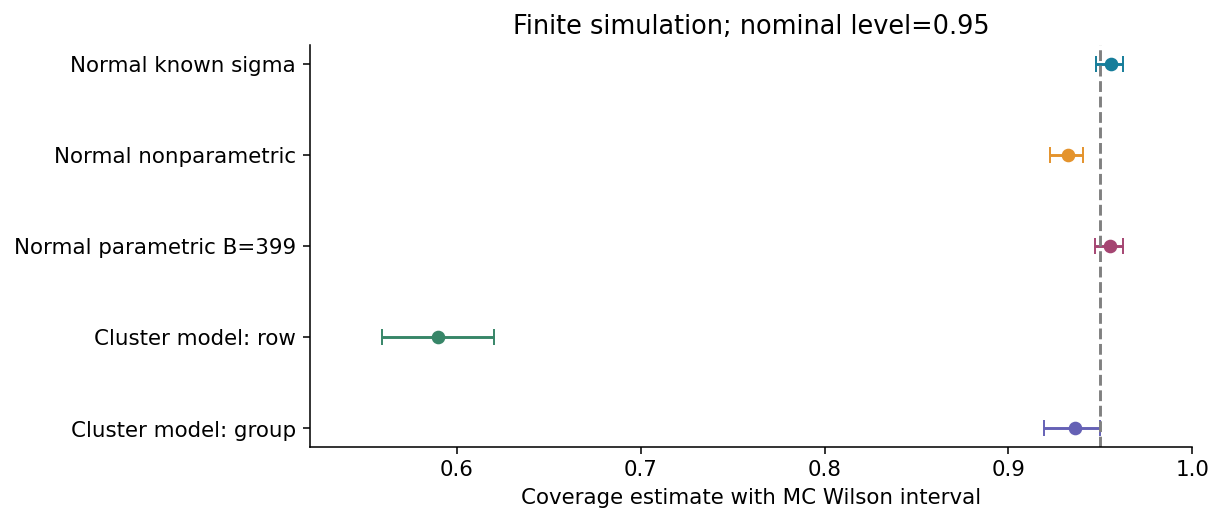

In [8]:
result=e.simulation(spec)
for section in ['normal','group']:
    for name,summary in result[section].items():
        print(section,name,summary)
fig,ax=plt.subplots(figsize=(9,4))
labels=['Normal known sigma','Normal nonparametric','Normal parametric B=399','Cluster model: row','Cluster model: group']
summaries=list(result['normal'].values())+list(result['group'].values())
colors=['#167d9a','#e4932c','#a54572','#378668','#6561b5']
for i,s in enumerate(summaries):
    lo,hi=s['mc_wilson95'];ax.errorbar(s['coverage'],i,xerr=[[s['coverage']-lo],[hi-s['coverage']]],fmt='o',capsize=4,color=colors[i])
ax.axvline(.95,ls='--',color='gray');ax.set(yticks=range(5),yticklabels=labels,xlim=(.52,1),xlabel='Coverage estimate with MC Wilson interval',title='Finite simulation; nominal level=0.95');ax.invert_yaxis()
show(fig)

### 8. 看真实重复抽样区间
竖线是真均值3，彩色区间随数据移动。前65次只是示意，不是额外独立实验。

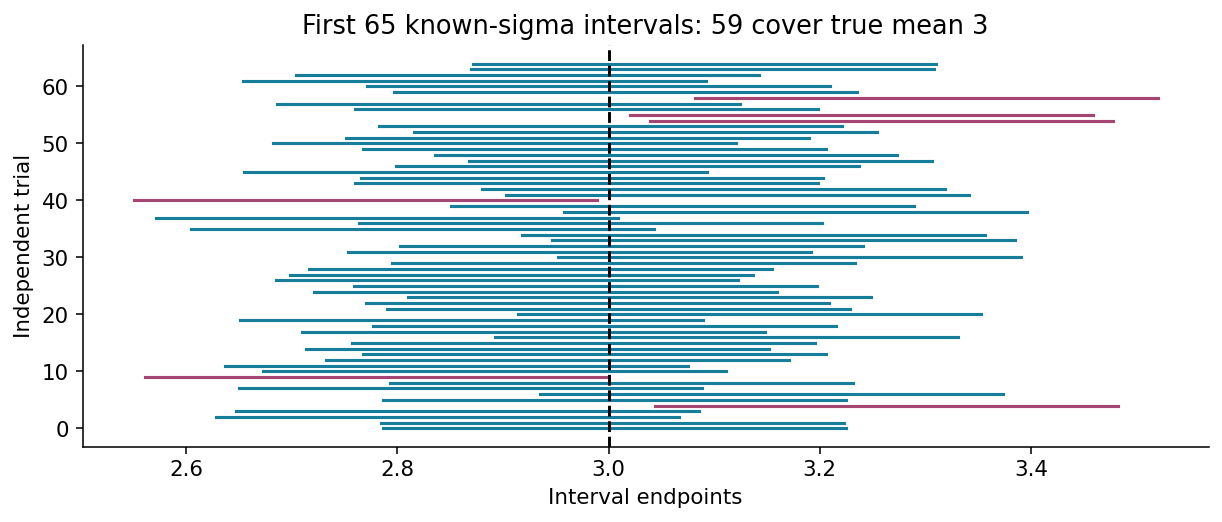

In [9]:
ci=np.array(result['normal_intervals']['known_sigma'][:65]);hits=(ci[:,0]<=3)&(3<=ci[:,1])
fig,ax=plt.subplots(figsize=(9,4))
for i,(lo,hi) in enumerate(ci):
    ax.plot([lo,hi],[i,i],color='#167d9a' if hits[i] else '#a54572',lw=1.6)
ax.axvline(3,ls='--',color='black');ax.set(xlabel='Interval endpoints',ylabel='Independent trial',title=f'First 65 known-sigma intervals: {hits.sum()} cover true mean 3')
show(fig)

## Checks
### 9. 完整输入验证与有限模拟复现
显式require不会因python -O被移除。这里测试最后一项、零权重项、未用的sigma分支和组输入。作者另以RNG替身检验错误输入在随机生成之前被拒绝。

In [10]:
invalid=[lambda:e.sample_sd([1,1,True]),lambda:e.bootstrap_mean([0,2,float('nan')],99),lambda:e.bootstrap_mean([0,2],sigma='2'),lambda:e.weighted_quantile([0,float('nan')],[1,0],.5),lambda:e.group_bootstrap([[0,0],[2,True]])]
for call in invalid:
    try:call()
    except ValueError:print('invalid input rejected')
    else:raise RuntimeError('invalid input accepted')
e.require(result['normal']['known_sigma']['hits']==2867,'baseline known-sigma hits')
e.require(result['normal']['nonparametric_percentile']['hits']==2797,'baseline nonparametric hits')
e.require(result['group']['row_percentile']['hits']==590,'baseline row hits')
e.require(result['group']['group_percentile']['hits']==936,'baseline group hits')
print(e.self_test())
print('All sequential tutorial checks passed.')

invalid input rejected
invalid input rejected
invalid input rejected
invalid input rejected
invalid input rejected
{'status': 'passed', 'checks': 9}
All sequential tutorial checks passed.


## Next Steps
按lab.pdf先写方向预测，再更改G、m、tau、R或B。不要挑选让图更接近95%的种子。完整证明、失败条件及数值域见lecture.pdf；答案见answers.pdf。

参数与非参数Bootstrap都不能补回未观察到的稀有尾部。正确抽样单位很重要，但它本身不保证有限n的精确95%覆盖。该Notebook已用新进程中的真实IPython InProcessKernel逐格执行并保留PNG；Anaconda安装、浏览器UI和socket传输未在作者环境测试。

来源：[NIST区间解释](https://www.itl.nist.gov/div898/handbook/eda/section3/eda352.htm)、[Shalizi作者Bootstrap讲义](https://stat.cmu.edu/~cshalizi/dst/18/lectures/18/lecture-18.html)、[NumPy quantile](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html)。更多来源与检查范围在source-checks.json。